## 04 — Embedding Analysis

วิเคราะห์ embedding ที่ neural models เรียนรู้ — ทำตามรอย Finding-Tori
(Han et al. 2023, ISMIR) แต่ adapt จาก audio F0 contour → symbolic Thai notation
และเพิ่ม representation learning triangulation 3 variants ที่ Finding-Tori ไม่มี

## เป้าหมายของ notebook นี้

1. Embedding ที่ neural model เรียนรู้สะท้อนอะไร: instrument idiom, piece identity, หรือทั้งคู่?
2. SSL pre-training (intra-song similarity) ทำงานบน symbolic Thai notation ไหม
3. เปรียบเทียบ embedding 8 schemes ด้วย 3 metrics: RF + kNN classification + nDCG retrieval
4. UMAP visualization เพื่อค้นพบ clusters ที่นักดนตรีอาจตีความได้

## ทำตามรอย Finding-Tori

| ส่วน | Finding-Tori | ของเรา |
|---|---|---|
| Input | audio F0 contour (continuous) | symbolic tokens (discrete) |
| Target concept | tori (regional style) | instrument identity |
| Window | 30 sec audio (600 timesteps) | 16 bars (~64 tokens) |
| Dataset | ~700 hours audio | 819 windows (much smaller) |
| Baseline | pitch histogram | hand-crafted features (notebook 02) |
| Architecture | 1D CNN | CNN, BiLSTM, Transformer + Thai-Beat-Counter |
| SSL signal | same song = positive (1 variant) | 3 variants (2 SSL + 1 SupCon) |
| Evaluation protocol | train SSL บน unlabeled corpus, evaluate บน labeled subset (no overlap) | per-fold honest CV (เพราะ corpus = labeled set) |

## Representation learning triangulation — innovation ของเรา

Finding-Tori ใช้ SSL signal เดียว: "fragment เดียวกันมาจาก song เดียวกัน"
ของเรา compare 3 paradigms ของ representation learning เพื่อตอบว่าสัญญาณไหนสำคัญที่สุด:

| Variant | Paradigm | Positive pair | บอกอะไร |
|---|---|---|---|
| **SSL-A: intra-song** | true SSL (no label) | 2 windows จาก song เดียวกัน | Finding-Tori signal |
| **SSL-B: cross-instrument** | true SSL (no label) | 2 windows จาก piece เดียวกัน แต่ instrument ต่างกัน | piece coherence |
| **SupCon-inst: cross-piece same-instrument** | supervised contrastive (ใช้ instrument label) | 2 windows จาก instrument เดียวกัน แต่ piece ต่างกัน | instrument idiom |

ความต่างของ 3 embeddings = สัญญาณที่ data มีจริง + ผลของ paradigm
SupCon ใช้ instrument label ผ่าน pair selection — ไม่ใช่ self-supervised อีกต่อไป
แต่ค่ายังเป็น embedding-based learning ที่ต่างจาก CE classification

## Per-fold honest evaluation (ครอบทั้ง notebook)

เพื่อให้ตัวเลขทุก scheme เปรียบเทียบกันได้ตรง ๆ ใช้ leave-one-piece-out CV
สำหรับ training ของ neural ทุกตัว:

- Section 3 supervised CE: train per fold → extract train+test embeddings จาก same model
- Section 5 SSL/SupCon: train per fold (บน train_idx เท่านั้น) → extract train+test embeddings จาก same model

→ ตัวเลขทุก scheme ใช้ same protocol, comparable

## โครงสร้าง 7 sections

| Section | หัวข้อ |
|---|---|
| 1 | Setup + load |
| 2 | Baseline: hand-crafted features |
| 3 | Supervised CE per-fold evaluation |
| 4 | UMAP visualization |
| 5 | SSL/SupCon per-fold evaluation |
| 6 | Compare 8 embedding schemes |
| 7 | Musicological findings |

## Output

- `results/tables/embedding_evaluation_full.csv` — 8 schemes × 3 metrics
- `results/figures/umap_grid_4schemes.png` — UMAP visualization
- `results/figures/embedding_comparison_final.png` — Finding-Tori Table 1 style


## 1. Setup + load

โหลด data, build windows, prepare features สำหรับใช้ใน Section 2-6

ใน notebook นี้ — neural models ทั้งหมด (supervised CE + SSL + SupCon) จะ train
แบบ per-fold ใน Section 3 และ 5 เพื่อป้องกัน data leakage

ใช้สถาปัตยกรรมจาก notebook 03:
- ThaiCNN (256-dim)
- ThaiBiLSTM (256-dim)
- ThaiBeatCounter Transformer (128-dim)


In [1]:
import sys
import os
import urllib.request
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/02_FindingInstrument')
else:
    PROJECT_ROOT = Path.cwd().parent

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

# Thai font
FONT_URL = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
FONT_PATH = Path('/content/Sarabun-Regular.ttf') if IN_COLAB else Path.home() / 'Sarabun-Regular.ttf'
if not FONT_PATH.exists():
    urllib.request.urlretrieve(FONT_URL, FONT_PATH)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont(str(FONT_PATH))
plt.rcParams['font.family'] = 'Sarabun'
plt.rcParams['axes.unicode_minus'] = False

# Reload utils
import importlib
import src.utils
importlib.reload(src.utils)

from src.utils import (
    load_notes, build_windows, compute_features_dataframe,
    make_cv_splits, set_seed, save_fig, save_table,
    INSTRUMENTS, PIECES, FEATURE_COLS,
    LOW_MARK, HIGH_MARK, SUSTAIN, NOTE_BASES,
)

import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

set_seed(42)

# Load + prepare
df = load_notes()
df['section'] = df['section'].fillna('สาธุการ')
windows_df = build_windows(df, window_size=16, stride=8)
features_df = compute_features_dataframe(windows_df)

inst_to_idx = {inst: i for i, inst in enumerate(INSTRUMENTS)}
windows_labels = features_df['instrument'].map(inst_to_idx).values

inst_colors = {
    'ขลุ่ย-ปี่':   '#4477aa',
    'ฆ้องวงใหญ่': '#ee7733',
    'ซออู้':       '#228833',
    'ระนาดเอก':    '#cc3366',
}

print(f"\n✓ data: {len(df):,} bars, {len(windows_df)} windows")


Mounted at /content/drive
Device: cuda
GPU: Tesla T4

✓ data: 6,760 bars, 819 windows


In [2]:
# Vocab — token IDs
PAD_ID = 0
UNK_ID = 1
all_tokens_in_data = sorted(set(t for tokens in windows_df['tokens'] for t in tokens))
token_to_id = {'<PAD>': PAD_ID, '<UNK>': UNK_ID}
for tok in all_tokens_in_data:
    token_to_id[tok] = len(token_to_id)
id_to_token = {v: k for k, v in token_to_id.items()}
VOCAB_SIZE = len(token_to_id)

def encode_tokens(tokens, vocab=token_to_id):
    return [vocab.get(t, UNK_ID) for t in tokens]


# Flat dataset (CNN + BiLSTM + SSL)
class NotationDataset(Dataset):
    def __init__(self, windows_subset, labels_subset):
        self.sequences = [encode_tokens(toks) for toks in windows_subset['tokens']]
        self.labels = labels_subset

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = torch.tensor(self.sequences[idx], dtype=torch.long)
        length = len(seq)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return seq, length, label


def collate_pad(batch):
    sequences, lengths, labels = zip(*batch)
    max_len = max(lengths)
    padded = torch.full((len(sequences), max_len), PAD_ID, dtype=torch.long)
    for i, seq in enumerate(sequences):
        padded[i, :len(seq)] = seq
    return padded, torch.tensor(lengths), torch.stack(labels)


# Facet vocab (TBC)
NOTE_BASE_TO_ID = {SUSTAIN: 0}
for i, b in enumerate(NOTE_BASES, start=1):
    NOTE_BASE_TO_ID[b] = i
NOTE_BASE_VOCAB = len(NOTE_BASE_TO_ID) + 1
NOTE_BASE_PAD = NOTE_BASE_VOCAB - 1

OCTAVE_TO_ID = {'sustain': 0, 'low': 1, 'mid': 2, 'high': 3}
OCTAVE_VOCAB = len(OCTAVE_TO_ID) + 1
OCTAVE_PAD = OCTAVE_VOCAB - 1


def encode_token_facets(token):
    if token == SUSTAIN:
        return NOTE_BASE_TO_ID[SUSTAIN], OCTAVE_TO_ID['sustain']
    base = token.replace(LOW_MARK, '').replace(HIGH_MARK, '')
    base_id = NOTE_BASE_TO_ID.get(base, 0)
    if LOW_MARK in token:
        oct_id = OCTAVE_TO_ID['low']
    elif HIGH_MARK in token:
        oct_id = OCTAVE_TO_ID['high']
    else:
        oct_id = OCTAVE_TO_ID['mid']
    return base_id, oct_id


def build_factorized_features(window_row, df_bars):
    bars = df_bars[(df_bars['song_file'] == window_row['song_file']) &
                   (df_bars['bar_index'] >= window_row['start_bar']) &
                   (df_bars['bar_index'] <= window_row['end_bar'])]
    bars = bars.sort_values('bar_index')

    note_base_seq, octave_seq, lukabad_seq, paren_seq = [], [], [], []
    for _, bar in bars.iterrows():
        is_luka = 1 if bar['n_tokens'] >= 5 else 0
        has_par = 1 if bar['has_paren'] else 0
        for tok in bar['tokens']:
            nb, oc = encode_token_facets(tok)
            note_base_seq.append(nb)
            octave_seq.append(oc)
            lukabad_seq.append(is_luka)
            paren_seq.append(has_par)
    return note_base_seq, octave_seq, lukabad_seq, paren_seq


# Pre-compute facets
print("Pre-computing facet sequences...")
factorized = []
for _, w in tqdm(windows_df.iterrows(), total=len(windows_df)):
    nb, oc, lu, pa = build_factorized_features(w, df)
    factorized.append({'note_base': nb, 'octave': oc, 'is_lukabad': lu, 'has_paren': pa})

windows_df_facet = windows_df.copy()
windows_df_facet['note_base_seq']   = [f['note_base'] for f in factorized]
windows_df_facet['octave_seq']      = [f['octave'] for f in factorized]
windows_df_facet['is_lukabad_seq']  = [f['is_lukabad'] for f in factorized]
windows_df_facet['has_paren_seq']   = [f['has_paren'] for f in factorized]


class FacetDataset(Dataset):
    def __init__(self, windows_subset, labels_subset):
        self.note_base = [list(s) for s in windows_subset['note_base_seq']]
        self.octave    = [list(s) for s in windows_subset['octave_seq']]
        self.lukabad   = [list(s) for s in windows_subset['is_lukabad_seq']]
        self.paren     = [list(s) for s in windows_subset['has_paren_seq']]
        self.labels = labels_subset

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        length = len(self.note_base[idx])
        return {
            'note_base':  torch.tensor(self.note_base[idx], dtype=torch.long),
            'octave':     torch.tensor(self.octave[idx], dtype=torch.long),
            'is_lukabad': torch.tensor(self.lukabad[idx], dtype=torch.long),
            'has_paren':  torch.tensor(self.paren[idx], dtype=torch.long),
            'length':     length,
            'label':      torch.tensor(self.labels[idx], dtype=torch.long),
        }


def collate_facet(batch):
    max_len = max(item['length'] for item in batch)
    B = len(batch)
    out = {}
    for facet, pad_id in [('note_base', NOTE_BASE_PAD), ('octave', OCTAVE_PAD),
                          ('is_lukabad', 0), ('has_paren', 0)]:
        padded = torch.full((B, max_len), pad_id, dtype=torch.long)
        for i, item in enumerate(batch):
            seq = item[facet]
            padded[i, :len(seq)] = seq
        out[facet] = padded
    out['lengths'] = torch.tensor([item['length'] for item in batch], dtype=torch.long)
    out['labels']  = torch.stack([item['label'] for item in batch])
    return out


print(f"\n✓ vocab: {VOCAB_SIZE} tokens, NOTE_BASE_VOCAB: {NOTE_BASE_VOCAB}, OCTAVE_VOCAB: {OCTAVE_VOCAB}")


Pre-computing facet sequences...


  0%|          | 0/819 [00:00<?, ?it/s]


✓ vocab: 24 tokens, NOTE_BASE_VOCAB: 9, OCTAVE_VOCAB: 5


In [3]:
# Model classes — เหมือน notebook 03 แต่เพิ่ม encode() ที่ return embedding ก่อน classifier
class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.context = nn.Parameter(torch.randn(dim))

    def forward(self, x, mask=None):
        scores = (x @ self.context) / (x.size(-1) ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)
        weights = F.softmax(scores, dim=1)
        return (x * weights.unsqueeze(-1)).sum(dim=1)


class ThaiCNN(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128, n_classes=4, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.conv1 = nn.Conv1d(embed_dim, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.conv4 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(256, n_classes)

    def encode(self, x, lengths=None):
        # Return pooled embedding (256d) — ใช้ใน Section 3 evaluation
        x = self.embedding(x).transpose(1, 2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        if lengths is not None:
            mask = (torch.arange(x.size(2), device=x.device)[None, :] < lengths[:, None])
            mask = mask.unsqueeze(1).float()
            x = x * mask
            x = x.sum(dim=2) / mask.sum(dim=2)
        else:
            x = x.mean(dim=2)
        return x

    def forward(self, x, lengths=None):
        emb = self.encode(x, lengths)
        return self.classifier(self.dropout(emb))


class ThaiBiLSTM(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=128,
                 n_layers=2, n_classes=4, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0)
        self.attn = AttentionPool(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, n_classes)

    def encode(self, x, lengths):
        x = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(),
                                                    batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        mask = (torch.arange(out.size(1), device=out.device)[None, :] < lengths[:, None])
        return self.attn(out, mask=mask)

    def forward(self, x, lengths):
        emb = self.encode(x, lengths)
        return self.classifier(self.dropout(emb))


class ThaiBeatCounterTransformer(nn.Module):
    def __init__(self, d_model=128, n_heads=4, n_layers=2, dim_ff=256,
                 max_len=80, n_classes=4, dropout=0.3,
                 use_facets=('note_base', 'octave', 'is_lukabad', 'has_paren')):
        super().__init__()
        self.use_facets = use_facets
        self.embeddings = nn.ModuleDict()
        if 'note_base' in use_facets:
            self.embeddings['note_base'] = nn.Embedding(NOTE_BASE_VOCAB, d_model,
                                                         padding_idx=NOTE_BASE_PAD)
        if 'octave' in use_facets:
            self.embeddings['octave'] = nn.Embedding(OCTAVE_VOCAB, d_model,
                                                      padding_idx=OCTAVE_PAD)
        if 'is_lukabad' in use_facets:
            self.embeddings['is_lukabad'] = nn.Embedding(2, d_model)
        if 'has_paren' in use_facets:
            self.embeddings['has_paren'] = nn.Embedding(2, d_model)

        self.pos_embedding = nn.Embedding(max_len, d_model)
        self.max_len = max_len
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=dim_ff,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers,
                                              enable_nested_tensor=False)
        self.attn_pool = AttentionPool(d_model)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, n_classes)

    def encode(self, batch):
        lengths = batch['lengths']
        device_ = lengths.device
        first_facet = list(self.use_facets)[0]
        B, L = batch[first_facet].shape
        x = torch.zeros(B, L, self.embeddings[first_facet].embedding_dim, device=device_)
        for facet in self.use_facets:
            x = x + self.embeddings[facet](batch[facet])
        positions = torch.arange(L, device=device_).clamp(max=self.max_len - 1)
        x = x + self.pos_embedding(positions)[None, :, :]
        pad_mask = (torch.arange(L, device=device_)[None, :] >= lengths[:, None])
        x = self.encoder(x, src_key_padding_mask=pad_mask)
        return self.attn_pool(x, mask=~pad_mask)

    def forward(self, batch):
        emb = self.encode(batch)
        return self.classifier(self.dropout(emb))


print("✓ Model classes พร้อม — CNN (256d), BiLSTM (256d), TBC (128d)")


✓ Model classes พร้อม — CNN (256d), BiLSTM (256d), TBC (128d)


## 2. Baseline: hand-crafted features

ใช้ 7 hand-crafted features จาก notebook 02 เป็น "non-embedding baseline" แทน
pitch histogram ของ Finding-Tori:

- sustain_ratio, low_oct_ratio, mid_oct_ratio, high_oct_ratio,
  lukabad_density, paren_ratio, transition_entropy

เก็บ 2 versions เพื่อ verify scaler leak ไม่กระทบ:
- handcrafted_7d (raw) — scale ภายใน CV (zero leak)
- handcrafted_7d_scaled — global scale (สำหรับ UMAP)


In [4]:
from sklearn.preprocessing import StandardScaler

embeddings = {}  # global dict สำหรับเก็บทุก embedding scheme

X_handcrafted = features_df[FEATURE_COLS].values
embeddings['handcrafted_7d'] = X_handcrafted

scaler_global = StandardScaler()
embeddings['handcrafted_7d_scaled'] = scaler_global.fit_transform(X_handcrafted)

print(f"handcrafted_7d:        shape {X_handcrafted.shape}")
print(f"handcrafted_7d_scaled: shape {embeddings['handcrafted_7d_scaled'].shape}")
print(f"  features: {FEATURE_COLS}")


handcrafted_7d:        shape (819, 7)
handcrafted_7d_scaled: shape (819, 7)
  features: ['sustain_ratio', 'low_oct_ratio', 'mid_oct_ratio', 'high_oct_ratio', 'lukabad_density', 'paren_ratio', 'transition_entropy']


## 3. Supervised CE per-fold evaluation

รวม training + extraction + evaluation ใน loop เดียว เพื่อหลีกเลี่ยง data leakage
ที่จะเกิดถ้า train neural บน full data แล้ว extract embeddings ของทุก window

### ทำไม per-fold

ถ้า train บน full data:
- model เห็นทุก window ตอน train รวม test windows
- embeddings ของ test contain leaked information ผ่าน model weights
- ตัวเลข evaluation เป็น "in-sample fit" ไม่ใช่ generalization

### Approach — leave-one-piece-out (ตาม Finding-Tori spirit)

```
For each seed (3 seeds):
    For each fold (6 pieces):
        1. train neural on train_pieces only
        2. extract embeddings of train + test (SAME model)
        3. fit RF + kNN on train embeddings → predict test → fold acc
        4. accumulate test embeddings → emb_seed[test_idx]
    After 6 folds → emb_seed มี 819 honest test embeddings
    Compute nDCG บน emb_seed
After 3 seeds → average metrics
```

**Critical: ต้อง extract train + test จาก SAME model** — เพราะแต่ละ fold trains
a different model with rotated embedding space. ผสม embeddings ข้าม models จะทำให้
RF/kNN ฝึกบน inconsistent space และ fail

### 3 Metrics

| Metric | คำนวณยังไง | บอกอะไร |
|---|---|---|
| **RF accuracy** | Random Forest 100 trees (ตาม Finding-Tori Table 1) | classification capability |
| **kNN accuracy** | k-Nearest Neighbors (k=5, cosine distance) | local neighborhood quality |
| **nDCG retrieval** | rank windows ด้วย cosine sim, same instrument = relevant | global retrieval quality |

RF + kNN: 6 folds × 3 seeds = 18 runs per scheme
nDCG: คำนวณบน accumulated 819 test embeddings ต่อ seed, average 3 seeds

### Schemes ที่ evaluate ใน Section 3 (5 rows)

| Scheme | Training | Paradigm |
|---|---|---|
| handcrafted_7d_scaled (global scaler) | no training | feature engineering |
| handcrafted_7d (proper, in-CV scaler) | no training | feature engineering |
| cnn_256d | per-fold × 3 seeds | supervised CE |
| bilstm_256d | per-fold × 3 seeds | supervised CE |
| tbc_128d | per-fold × 3 seeds | supervised CE |


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize, StandardScaler


def evaluate_classification(emb, labels, scaler_inside_cv=False, n_seeds=3):
    # Leave-one-piece-out × seeds — return RF + kNN accuracy
    rf_accs, knn_accs = [], []
    for seed in range(n_seeds):
        for _, train_idx, test_idx in make_cv_splits(features_df, group_col='piece'):
            X_train, X_test = emb[train_idx], emb[test_idx]
            y_train, y_test = labels[train_idx], labels[test_idx]

            if scaler_inside_cv:
                sc = StandardScaler()
                X_train = sc.fit_transform(X_train)
                X_test = sc.transform(X_test)

            rf = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
            rf.fit(X_train, y_train)
            rf_accs.append(rf.score(X_test, y_test))

            X_train_n = normalize(X_train, axis=1)
            X_test_n = normalize(X_test, axis=1)
            knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
            knn.fit(X_train_n, y_train)
            knn_accs.append(knn.score(X_test_n, y_test))

    return {
        'rf_acc_mean':  np.mean(rf_accs),
        'rf_acc_std':   np.std(rf_accs),
        'knn_acc_mean': np.mean(knn_accs),
        'knn_acc_std':  np.std(knn_accs),
        'n_runs':       len(rf_accs),
    }


def evaluate_ndcg(emb, labels):
    # nDCG retrieval — same instrument = relevant
    emb_norm = normalize(emb, axis=1)
    sim_matrix = emb_norm @ emb_norm.T

    ndcg_scores = []
    for i in range(len(emb)):
        sim = sim_matrix[i].copy()
        sim[i] = -np.inf  # exclude self
        ranked_idx = np.argsort(-sim)
        relevance = (labels[ranked_idx] == labels[i]).astype(float)
        ideal = np.sort(relevance)[::-1]
        ranks = np.arange(1, len(relevance) + 1)
        dcg = (relevance / np.log2(ranks + 1)).sum()
        idcg = (ideal / np.log2(ranks + 1)).sum()
        if idcg > 0:
            ndcg_scores.append(dcg / idcg)

    return np.mean(ndcg_scores)


# Container สำหรับเก็บผลทุก scheme
emb_results = []

print("✓ evaluation functions พร้อม")
print("  Metrics: RF (100 trees), kNN (k=5 cosine), nDCG retrieval")
print("  Protocol: leave-one-piece-out × 3 seeds = 18 runs per scheme")


✓ evaluation functions พร้อม
  Metrics: RF (100 trees), kNN (k=5 cosine), nDCG retrieval
  Protocol: leave-one-piece-out × 3 seeds = 18 runs per scheme


In [6]:
# Hand-crafted baseline — 2 versions เพื่อ verify scaler leak ไม่กระทบ

# Version 1: global scaler (มี mini-leak)
cls = evaluate_classification(embeddings['handcrafted_7d_scaled'], windows_labels,
                                scaler_inside_cv=False, n_seeds=3)
ndcg = evaluate_ndcg(embeddings['handcrafted_7d_scaled'], windows_labels)
emb_results.append({
    'scheme': 'handcrafted_7d_scaled',
    'paradigm': 'feature engineering',
    'dim': 7,
    'rf_acc_mean':  cls['rf_acc_mean'], 'rf_acc_std':  cls['rf_acc_std'],
    'knn_acc_mean': cls['knn_acc_mean'], 'knn_acc_std': cls['knn_acc_std'],
    'ndcg': ndcg, 'ndcg_std': 0.0,
    'n_folds': cls['n_runs'],
})
print(f"handcrafted_7d_scaled       RF {cls['rf_acc_mean']:.3f}±{cls['rf_acc_std']:.3f}  "
      f"kNN {cls['knn_acc_mean']:.3f}±{cls['knn_acc_std']:.3f}  nDCG {ndcg:.3f}")

# Version 2: proper in-CV scaler (zero leak)
cls = evaluate_classification(embeddings['handcrafted_7d'], windows_labels,
                                scaler_inside_cv=True, n_seeds=3)
ndcg = evaluate_ndcg(embeddings['handcrafted_7d_scaled'], windows_labels)
emb_results.append({
    'scheme': 'handcrafted_7d (proper)',
    'paradigm': 'feature engineering',
    'dim': 7,
    'rf_acc_mean':  cls['rf_acc_mean'], 'rf_acc_std':  cls['rf_acc_std'],
    'knn_acc_mean': cls['knn_acc_mean'], 'knn_acc_std': cls['knn_acc_std'],
    'ndcg': ndcg, 'ndcg_std': 0.0,
    'n_folds': cls['n_runs'],
})
print(f"handcrafted_7d (proper)     RF {cls['rf_acc_mean']:.3f}±{cls['rf_acc_std']:.3f}  "
      f"kNN {cls['knn_acc_mean']:.3f}±{cls['knn_acc_std']:.3f}  nDCG {ndcg:.3f}")


handcrafted_7d_scaled       RF 0.549±0.072  kNN 0.523±0.093  nDCG 0.821
handcrafted_7d (proper)     RF 0.549±0.072  kNN 0.521±0.101  nDCG 0.821


In [7]:
# Per-fold neural training + extraction + evaluation
# Critical: extract train + test embeddings from SAME model (ป้องกัน rotation issue)

def evaluate_neural_perfold(model_factory, dataset_class, collate_fn, scheme_name, paradigm,
                             use_dict_input=False, seeds=(42, 123, 2024),
                             epochs=25, lr=1e-3, batch_size=32):
    n_windows = len(windows_df)
    rf_fold_accs = []
    knn_fold_accs = []
    ndcg_per_seed = []
    embeddings_per_seed = []

    for seed in seeds:
        set_seed(seed)
        emb_this_seed = None
        windows_filled = np.zeros(n_windows, dtype=bool)

        folds = list(make_cv_splits(features_df, group_col='piece'))
        for held_out, train_idx, test_idx in tqdm(folds, desc=f'{scheme_name} seed={seed}', leave=False):
            if use_dict_input:
                train_ds = dataset_class(windows_df_facet.iloc[train_idx], windows_labels[train_idx])
                test_ds  = dataset_class(windows_df_facet.iloc[test_idx],  windows_labels[test_idx])
            else:
                train_ds = dataset_class(windows_df.iloc[train_idx], windows_labels[train_idx])
                test_ds  = dataset_class(windows_df.iloc[test_idx],  windows_labels[test_idx])

            train_loader         = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn)
            train_loader_extract = DataLoader(train_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
            test_loader          = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

            # Train
            model = model_factory().to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
            criterion = nn.CrossEntropyLoss()
            model.train()
            for epoch in range(epochs):
                for batch in train_loader:
                    optimizer.zero_grad()
                    if use_dict_input:
                        batch = {k: v.to(device) for k, v in batch.items()}
                        loss = criterion(model(batch), batch['labels'])
                    else:
                        inputs, lengths, labels_ = [x.to(device) for x in batch]
                        loss = criterion(model(inputs, lengths), labels_)
                    loss.backward()
                    optimizer.step()

            # Extract embeddings (same model สำหรับ train + test)
            model.eval()
            def extract(loader):
                embs = []
                with torch.no_grad():
                    for batch in loader:
                        if use_dict_input:
                            batch = {k: v.to(device) for k, v in batch.items()}
                            embs.append(model.encode(batch).cpu().numpy())
                        else:
                            inputs, lengths, _ = batch
                            inputs, lengths = inputs.to(device), lengths.to(device)
                            embs.append(model.encode(inputs, lengths).cpu().numpy())
                return np.concatenate(embs, axis=0)

            train_embs = extract(train_loader_extract)
            test_embs  = extract(test_loader)

            if emb_this_seed is None:
                emb_this_seed = np.zeros((n_windows, test_embs.shape[1]), dtype=np.float32)

            emb_this_seed[test_idx] = test_embs
            windows_filled[test_idx] = True

            # Fold-level RF + kNN
            y_train, y_test = windows_labels[train_idx], windows_labels[test_idx]
            rf = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
            rf.fit(train_embs, y_train)
            rf_fold_accs.append(rf.score(test_embs, y_test))

            knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
            knn.fit(normalize(train_embs, axis=1), y_train)
            knn_fold_accs.append(knn.score(normalize(test_embs, axis=1), y_test))

            del model
            torch.cuda.empty_cache()

        assert windows_filled.all(), "ไม่ครบทุก window!"
        ndcg_per_seed.append(evaluate_ndcg(emb_this_seed, windows_labels))
        embeddings_per_seed.append(emb_this_seed)

    result = {
        'scheme':       scheme_name,
        'paradigm':     paradigm,
        'dim':          embeddings_per_seed[0].shape[1],
        'rf_acc_mean':  np.mean(rf_fold_accs),
        'rf_acc_std':   np.std(rf_fold_accs),
        'knn_acc_mean': np.mean(knn_fold_accs),
        'knn_acc_std':  np.std(knn_fold_accs),
        'ndcg':         np.mean(ndcg_per_seed),
        'ndcg_std':     np.std(ndcg_per_seed),
        'n_folds':      len(rf_fold_accs),
    }
    print(f"\n{scheme_name:25s}  paradigm: {paradigm}")
    print(f"  RF {result['rf_acc_mean']:.3f}±{result['rf_acc_std']:.3f}  "
          f"kNN {result['knn_acc_mean']:.3f}±{result['knn_acc_std']:.3f}  "
          f"nDCG {result['ndcg']:.3f}±{result['ndcg_std']:.3f}")
    return result, embeddings_per_seed


print("✓ evaluate_neural_perfold พร้อม")
print("  Train per fold → extract train+test (same model) → fit RF/kNN → evaluate")


✓ evaluate_neural_perfold พร้อม
  Train per fold → extract train+test (same model) → fit RF/kNN → evaluate


In [8]:
print("=" * 60)
print("CNN per-fold (supervised CE)")
print("=" * 60)

result_cnn, cnn_emb_list = evaluate_neural_perfold(
    model_factory=lambda: ThaiCNN(),
    dataset_class=NotationDataset,
    collate_fn=collate_pad,
    scheme_name='cnn_256d',
    paradigm='supervised CE',
    use_dict_input=False,
)
emb_results.append(result_cnn)
embeddings['cnn_256d'] = cnn_emb_list


CNN per-fold (supervised CE)


cnn_256d seed=42:   0%|          | 0/6 [00:00<?, ?it/s]

cnn_256d seed=123:   0%|          | 0/6 [00:00<?, ?it/s]

cnn_256d seed=2024:   0%|          | 0/6 [00:00<?, ?it/s]


cnn_256d                   paradigm: supervised CE
  RF 0.667±0.103  kNN 0.675±0.097  nDCG 0.811±0.002


In [9]:
print("=" * 60)
print("BiLSTM per-fold (supervised CE)")
print("=" * 60)

result_bilstm, bilstm_emb_list = evaluate_neural_perfold(
    model_factory=lambda: ThaiBiLSTM(),
    dataset_class=NotationDataset,
    collate_fn=collate_pad,
    scheme_name='bilstm_256d',
    paradigm='supervised CE',
    use_dict_input=False,
)
emb_results.append(result_bilstm)
embeddings['bilstm_256d'] = bilstm_emb_list


BiLSTM per-fold (supervised CE)


bilstm_256d seed=42:   0%|          | 0/6 [00:00<?, ?it/s]

bilstm_256d seed=123:   0%|          | 0/6 [00:00<?, ?it/s]

bilstm_256d seed=2024:   0%|          | 0/6 [00:00<?, ?it/s]


bilstm_256d                paradigm: supervised CE
  RF 0.674±0.073  kNN 0.682±0.068  nDCG 0.809±0.001


In [10]:
print("=" * 60)
print("TBC per-fold (supervised CE, factorized facets)")
print("=" * 60)

result_tbc, tbc_emb_list = evaluate_neural_perfold(
    model_factory=lambda: ThaiBeatCounterTransformer(),
    dataset_class=FacetDataset,
    collate_fn=collate_facet,
    scheme_name='tbc_128d',
    paradigm='supervised CE',
    use_dict_input=True,
)
emb_results.append(result_tbc)
embeddings['tbc_128d'] = tbc_emb_list


TBC per-fold (supervised CE, factorized facets)


tbc_128d seed=42:   0%|          | 0/6 [00:00<?, ?it/s]

tbc_128d seed=123:   0%|          | 0/6 [00:00<?, ?it/s]

tbc_128d seed=2024:   0%|          | 0/6 [00:00<?, ?it/s]


tbc_128d                   paradigm: supervised CE
  RF 0.652±0.071  kNN 0.641±0.076  nDCG 0.802±0.005


,scheme,paradigm,dim,rf_acc_mean,rf_acc_std,knn_acc_mean,knn_acc_std,ndcg,ndcg_std,n_folds
0,handcrafted_7d_scaled,feature engineering,7,0.5490,0.0724,0.5230,0.0930,0.8209,0.0000,18
1,handcrafted_7d (proper),feature engineering,7,0.5487,0.0723,0.5206,0.1012,0.8209,0.0000,18
2,cnn_256d,supervised CE,256,0.6672,0.1031,0.6752,0.0970,0.8110,0.0022,18
3,bilstm_256d,supervised CE,256,0.6737,0.0734,0.6824,0.0677,0.8091,0.0014,18
4,tbc_128d,supervised CE,128,0.6521,0.0713,0.6411,0.0762,0.8022,0.0048,18


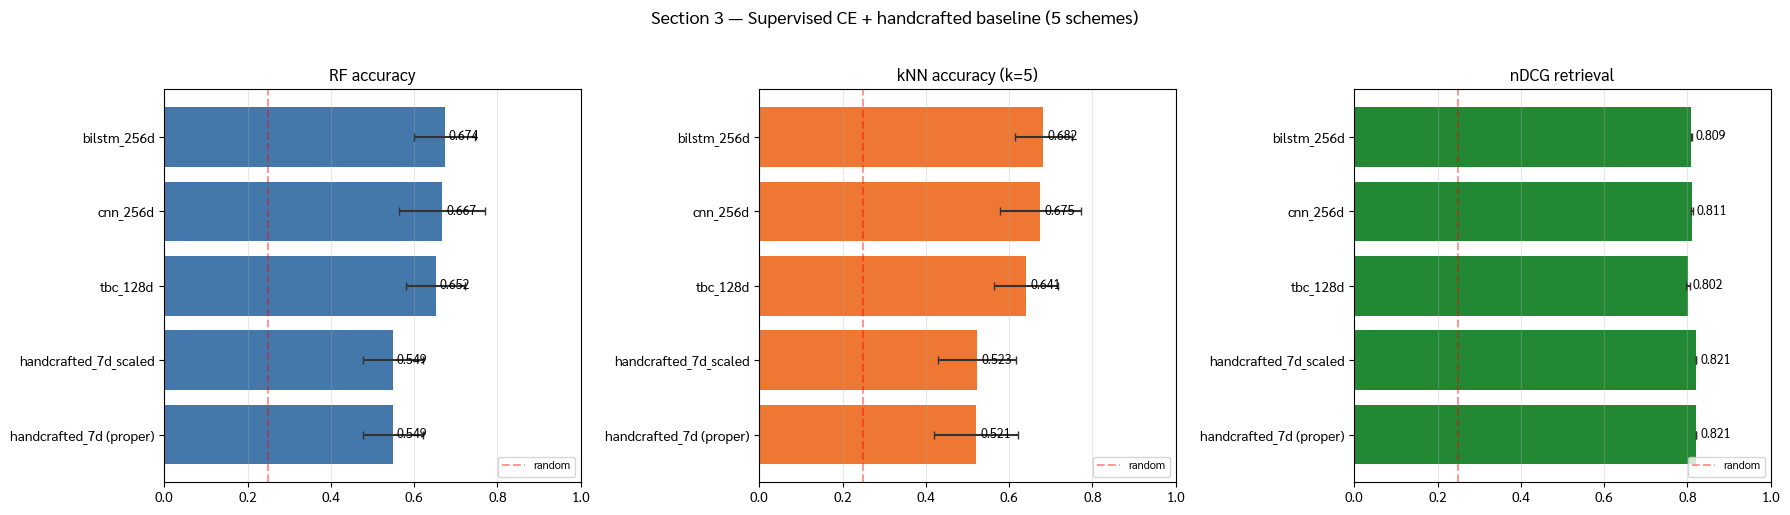


✓ saved → embedding_evaluation_classifier.csv + embedding_classifier_eval.png


In [11]:
# Section 3 intermediate plot + save (รวมทั้งหมดอีกครั้งใน Section 6)
emb_df = pd.DataFrame(emb_results).round(4)
display(emb_df)
save_table(emb_df, 'embedding_evaluation_classifier')

emb_df_sorted = emb_df.sort_values('rf_acc_mean').reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [
    ('rf_acc_mean', 'rf_acc_std', 'RF accuracy', '#4477aa'),
    ('knn_acc_mean', 'knn_acc_std', 'kNN accuracy (k=5)', '#ee7733'),
    ('ndcg', 'ndcg_std', 'nDCG retrieval', '#228833'),
]

for ax, (mean_col, std_col, title, color) in zip(axes, metrics):
    std_vals = emb_df_sorted[std_col].fillna(0).values
    bars = ax.barh(emb_df_sorted['scheme'], emb_df_sorted[mean_col],
                    xerr=std_vals, color=color, error_kw={'ecolor': '#333', 'capsize': 3})
    for bar, val in zip(bars, emb_df_sorted[mean_col]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 1.0)
    ax.axvline(0.25, color='red', linestyle='--', alpha=0.4, label='random')
    ax.grid(axis='x', alpha=0.3)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Section 3 — Supervised CE + handcrafted baseline (5 schemes)', fontsize=13, y=1.02)
plt.tight_layout()
save_fig('embedding_classifier_eval')
plt.show()
print("\n✓ saved → embedding_evaluation_classifier.csv + embedding_classifier_eval.png")


## 4. UMAP visualization

ลดมิติ embeddings ลง 2D ด้วย UMAP (McInnes et al. 2018) เพื่อเห็น cluster structure

### ตามรอย Finding-Tori Figure 4

Finding-Tori ทำ UMAP แล้ว color ด้วยหลาย metadata: tori label, subdivided tori,
piece variant, region. พบ cluster ที่ region label มองไม่เห็น —
SSL embedding capture musical concept ที่ลึกกว่า surface metadata

### Plan ของเรา

ใช้ metadata 2 axes สำหรับ color:
- **instrument** (4 classes) — primary target concept
- **piece** (6 pieces) — control variable

แสดง 4 schemes × 2 colors = 8 panels

### คำถามที่อยากตอบ

1. **Instrument separation:** embedding แยก 4 เครื่องชัดไหม?
2. **Piece bias:** windows จาก piece เดียวกันรวมกัน หรือกระจาย?
3. **Hand-crafted vs neural:** neural ดีกว่า baseline ขนาดไหน?

### Note: ใช้ seed 0 ของ neural

Neural embedding ของแต่ละ seed มี space rotation ต่างกัน — ไม่สามารถวาดหลาย seeds
ใน coordinate เดียวกัน เลือก seed 0 มาวาด, std จาก 3 seeds รายงานใน Section 3


In [12]:
try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'umap-learn'], check=True)
    import umap

print("Computing UMAP for 4 schemes...")

umap_inputs = {
    'handcrafted_7d_scaled': embeddings['handcrafted_7d_scaled'],
    'cnn_256d (seed 0)':     embeddings['cnn_256d'][0],
    'bilstm_256d (seed 0)':  embeddings['bilstm_256d'][0],
    'tbc_128d (seed 0)':     embeddings['tbc_128d'][0],
}

umap_2d = {}
for name, emb in umap_inputs.items():
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                         metric='cosine', random_state=42)
    umap_2d[name] = reducer.fit_transform(emb)
    print(f"  {name}: {emb.shape} → {umap_2d[name].shape}")

labels_inst = features_df['instrument'].values
labels_piece = features_df['piece'].values

piece_unique = sorted(set(labels_piece))
piece_colors = {p: plt.cm.Set2(i / max(len(piece_unique), 1)) for i, p in enumerate(piece_unique)}

print(f"\n✓ UMAP computed for {len(umap_2d)} schemes")
print(f"  Pieces ({len(piece_unique)}): {piece_unique}")


Computing UMAP for 4 schemes...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  handcrafted_7d_scaled: (819, 7) → (819, 2)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  cnn_256d (seed 0): (819, 256) → (819, 2)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  bilstm_256d (seed 0): (819, 256) → (819, 2)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  tbc_128d (seed 0): (819, 128) → (819, 2)

✓ UMAP computed for 4 schemes
  Pieces (6): ['กล่อมนารี', 'จีนขิมเล็ก', 'ตับต้นเพลงฉิ่ง', 'สาธุการ', 'แขกมอญบางช้าง', 'โหมโรงมหาฤกษ์']


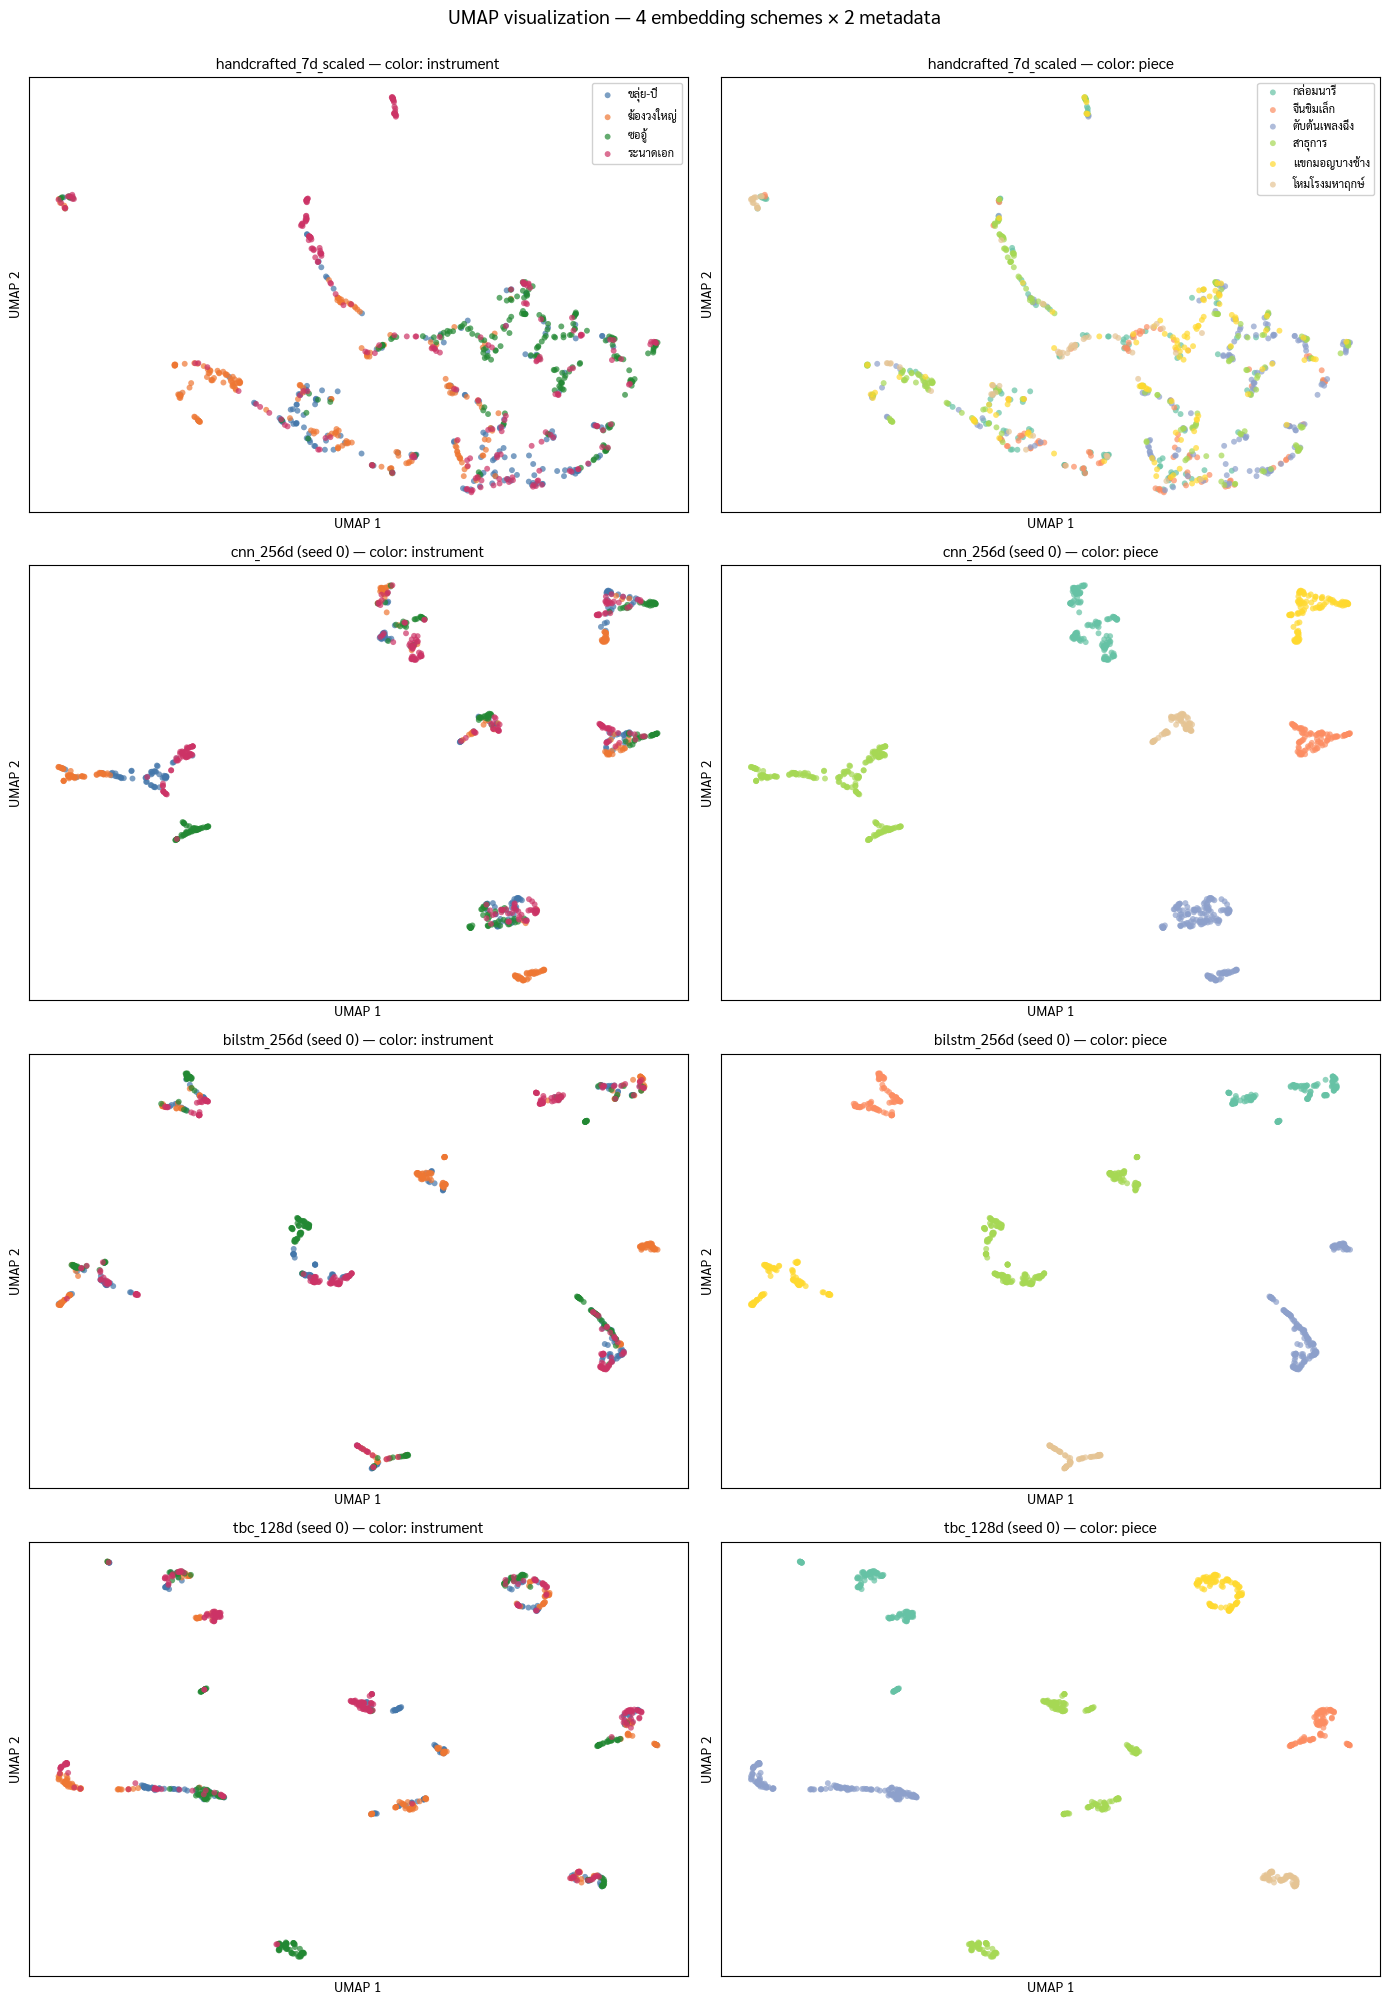

✓ saved → umap_grid_4schemes.png


In [13]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))

schemes = list(umap_2d.keys())

for row, scheme in enumerate(schemes):
    coords = umap_2d[scheme]

    ax = axes[row, 0]
    for inst in INSTRUMENTS:
        mask = labels_inst == inst
        ax.scatter(coords[mask, 0], coords[mask, 1],
                    c=inst_colors[inst], label=inst, s=18, alpha=0.7, edgecolors='none')
    ax.set_title(f'{scheme} — color: instrument', fontsize=11)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    if row == 0:
        ax.legend(loc='best', fontsize=8, framealpha=0.9)
    ax.set_xticks([])
    ax.set_yticks([])

    ax = axes[row, 1]
    for piece in piece_unique:
        mask = labels_piece == piece
        ax.scatter(coords[mask, 0], coords[mask, 1],
                    c=[piece_colors[piece]], label=piece, s=18, alpha=0.7, edgecolors='none')
    ax.set_title(f'{scheme} — color: piece', fontsize=11)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    if row == 0:
        ax.legend(loc='best', fontsize=8, framealpha=0.9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('UMAP visualization — 4 embedding schemes × 2 metadata',
              fontsize=14, y=1.00)
plt.tight_layout()
save_fig('umap_grid_4schemes')
plt.show()
print("✓ saved → umap_grid_4schemes.png")


## 5. SSL/SupCon per-fold evaluation — Triangulation (HONEST)

### ทำตามรอย Finding-Tori — Triplet loss

Finding-Tori ใช้ triplet loss intra-song:
```
L = max(0, m - Sim(anchor, positive) + Sim(anchor, negative))
```
- m = 0.4 (hinge margin)
- 8 negatives per anchor
- cosine similarity

### Honest per-fold training — ต่างจาก Finding-Tori

Finding-Tori train SSL บน **unlabeled corpus** (700hr) แล้ว evaluate บน **labeled subset** (218 songs)
— ไม่มี overlap ระหว่าง train และ evaluate

ของเรา dataset เล็ก: 24 song files = labeled set ทั้งหมด — ไม่มี unlabeled corpus แยก
ดังนั้น **ใช้ per-fold protocol** เพื่อให้ honest:

```
For each seed (3 seeds):
    For each fold (6 pieces):
        1. train SSL/SupCon บน train_idx (windows ของ 5 pieces)
        2. extract embeddings of train + test from SAME model
        3. fit RF + kNN on train embeddings → predict test
        4. accumulate test embeddings → emb_seed[test_idx]
    After 6 folds → emb_seed มี 819 honest test embeddings
    Compute nDCG บน emb_seed
After 3 seeds → average metrics
```

### Triangulation — 3 paradigms

ใน Thai music ของเรา 24 song files = 4 instruments × 6 pieces — โครงสร้าง 2 มิตินี้
ทำให้สามารถออกแบบ positive/negative pair ได้ 3 แบบ:

| Variant | Paradigm | Anchor & Positive | Negative |
|---|---|---|---|
| **SSL-A: intra-song** | true SSL | 2 windows จาก **song file เดียวกัน** | 8 windows จาก song อื่น |
| **SSL-B: cross-instrument** | true SSL | 2 windows จาก **piece เดียวกัน** (instruments ต่างกัน) | 8 windows จาก piece อื่น |
| **SupCon-inst** | supervised contrastive (uses label) | 2 windows จาก **instrument เดียวกัน** (pieces ต่างกัน) | 8 windows จาก instrument อื่น |

**Paradigm note:**
SSL-A และ SSL-B = **true self-supervised** — positive/negative มาจาก metadata
ที่ไม่ใช่ instrument label (song_file, piece) → ไม่ใช้ instrument label เลย

SupCon-inst = **supervised contrastive learning** — positive/negative ใช้ instrument
label ในการ select pairs → ใช้ label ทางอ้อม ไม่ใช่ "self-supervised" อีกต่อไป

### Architecture

- CNN backbone เดียวกับ Pillar 3 (256-dim) — remove classifier, add projection head
- Projection: 256 → 128, L2-normalize ที่ output (สำหรับ cosine similarity)
- Train 30 epochs ด้วย triplet loss

### คาดการณ์เวลา

54 trainings (3 variants × 3 seeds × 6 folds) × ~33 sec = ~30 นาที


In [14]:
# SSL CNN — same backbone as supervised CNN, replace classifier with projection head
class SSLCNN(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128, proj_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.conv1 = nn.Conv1d(embed_dim, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.conv4 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(256)
        self.projection = nn.Sequential(
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, proj_dim)
        )

    def encode(self, x, lengths=None):
        # Return 256-dim embedding ก่อน projection — ใช้ตอน evaluate
        x = self.embedding(x).transpose(1, 2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        if lengths is not None:
            mask = (torch.arange(x.size(2), device=x.device)[None, :] < lengths[:, None])
            mask = mask.unsqueeze(1).float()
            x = x * mask
            x = x.sum(dim=2) / mask.sum(dim=2)
        else:
            x = x.mean(dim=2)
        return x

    def forward(self, x, lengths=None):
        # Return projected + L2-normalized embedding สำหรับ SSL loss
        z = self.encode(x, lengths)
        z = self.projection(z)
        z = F.normalize(z, p=2, dim=1)
        return z


def triplet_loss_cosine(anchor, positive, negatives, margin=0.4):
    # All L2-normalized → dot product = cosine similarity
    # anchor: (B, D), positive: (B, D), negatives: (B, n_neg, D)
    sim_pos = (anchor * positive).sum(dim=1)
    sim_neg = torch.einsum('bd,bnd->bn', anchor, negatives)
    losses = F.relu(margin - sim_pos.unsqueeze(1) + sim_neg)
    return losses.mean()


print("✓ SSLCNN + triplet_loss_cosine พร้อม")
print(f"  Embed dim: 256 (encode), Projection dim: 128 (loss)")
print(f"  Triplet margin: 0.4, n_negatives: 8 (ตาม Finding-Tori)")


✓ SSLCNN + triplet_loss_cosine พร้อม
  Embed dim: 256 (encode), Projection dim: 128 (loss)
  Triplet margin: 0.4, n_negatives: 8 (ตาม Finding-Tori)


In [15]:
# Build peer indices (global) + sampler ที่ใช้ pool_mask สำหรับ per-fold training

song_files            = features_df['song_file'].values
pieces_per_window     = features_df['piece'].values
instruments_per_window = features_df['instrument'].values

print("Building peer indices...")
n = len(features_df)
same_song = [None] * n
same_piece_diff_inst = [None] * n
same_inst_diff_piece = [None] * n

for i in range(n):
    my_song = song_files[i]
    my_piece = pieces_per_window[i]
    my_inst = instruments_per_window[i]
    same_song[i] = np.where(song_files == my_song)[0]
    same_piece_diff_inst[i] = np.where(
        (pieces_per_window == my_piece) & (instruments_per_window != my_inst)
    )[0]
    same_inst_diff_piece[i] = np.where(
        (instruments_per_window == my_inst) & (pieces_per_window != my_piece)
    )[0]

print(f"✓ peer indices คำนวณเสร็จ (n={n})")


def sample_triplet_in_pool(anchor_idx, variant, pool_mask, n_neg=8, rng=None):
    # Sample 1 positive + n_neg negatives — restricted to pool_mask (train pool)
    # anchor_idx ต้องอยู่ใน pool_mask, positive/negative มาจาก pool_mask เท่านั้น
    if rng is None:
        rng = np.random
    my_song = song_files[anchor_idx]
    my_piece = pieces_per_window[anchor_idx]
    my_inst = instruments_per_window[anchor_idx]

    if variant == 'A':
        pos_pool = same_song[anchor_idx]
        pos_pool = pos_pool[(pos_pool != anchor_idx) & pool_mask[pos_pool]]
        neg_mask_full = (song_files != my_song) & pool_mask
    elif variant == 'B':
        pos_pool = same_piece_diff_inst[anchor_idx]
        pos_pool = pos_pool[pool_mask[pos_pool]]
        neg_mask_full = (pieces_per_window != my_piece) & pool_mask
    elif variant == 'C':
        pos_pool = same_inst_diff_piece[anchor_idx]
        pos_pool = pos_pool[pool_mask[pos_pool]]
        neg_mask_full = (instruments_per_window != my_inst) & pool_mask
    else:
        raise ValueError(f"Unknown variant: {variant}")

    if len(pos_pool) == 0:
        return None

    pos_idx = rng.choice(pos_pool)

    neg_candidates = np.where(neg_mask_full)[0]
    if len(neg_candidates) < n_neg:
        return None
    neg_idx = rng.choice(neg_candidates, size=n_neg, replace=False)

    return pos_idx, neg_idx


# Test sampler บน fold แรก
test_folds = list(make_cv_splits(features_df, group_col='piece'))
held_out_test, train_idx_test, test_idx_test = test_folds[0]
pool_mask_test = np.zeros(n, dtype=bool)
pool_mask_test[train_idx_test] = True

print(f"\nTest sampler on fold (held_out={held_out_test}):")
print(f"  train pool: {pool_mask_test.sum()} windows")

rng = np.random.RandomState(42)
anchor_idx = train_idx_test[0]
for variant in ['A', 'B', 'C']:
    result = sample_triplet_in_pool(anchor_idx, variant, pool_mask_test, rng=rng)
    if result:
        pos, neg = result
        print(f"  variant {variant}: anchor={anchor_idx} "
              f"({pieces_per_window[anchor_idx]}, {instruments_per_window[anchor_idx]})  "
              f"pos={pos} ({pieces_per_window[pos]}, {instruments_per_window[pos]})  "
              f"n_neg={len(neg)}")
    else:
        print(f"  variant {variant}: no triplet (insufficient pool)")


Building peer indices...
✓ peer indices คำนวณเสร็จ (n=819)

Test sampler on fold (held_out=กล่อมนารี):
  train pool: 679 windows
  variant A: anchor=29 (จีนขิมเล็ก, ขลุ่ย-ปี่)  pos=36 (จีนขิมเล็ก, ขลุ่ย-ปี่)  n_neg=8
  variant B: anchor=29 (จีนขิมเล็ก, ขลุ่ย-ปี่)  pos=658 (จีนขิมเล็ก, ระนาดเอก)  n_neg=8
  variant C: anchor=29 (จีนขิมเล็ก, ขลุ่ย-ปี่)  pos=135 (สาธุการ, ขลุ่ย-ปี่)  n_neg=8


In [16]:
# Honest per-fold SSL/SupCon — train บน train_idx, extract train+test จาก same model

def train_ssl_per_fold(variant, train_idx, epochs=30, batch_size=32,
                        n_neg=8, margin=0.4, lr=1e-3, seed=42):
    # Train SSL CNN on train_idx only — return trained model
    set_seed(seed)

    pool_mask = np.zeros(len(features_df), dtype=bool)
    pool_mask[train_idx] = True

    all_sequences = [encode_tokens(toks) for toks in windows_df['tokens']]

    model = SSLCNN(vocab_size=VOCAB_SIZE).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    rng = np.random.RandomState(seed)

    train_idx_arr = np.array(train_idx)
    n_train = len(train_idx_arr)

    for epoch in range(epochs):
        model.train()
        anchor_order = rng.permutation(train_idx_arr)
        epoch_loss = 0.0
        n_batches = 0

        for batch_start in range(0, n_train, batch_size):
            anchor_idxs = anchor_order[batch_start:batch_start + batch_size]

            anchors_seq, pos_seq, neg_seqs = [], [], []
            for aidx in anchor_idxs:
                result = sample_triplet_in_pool(aidx, variant, pool_mask, n_neg=n_neg, rng=rng)
                if result is None:
                    continue
                pos_idx, neg_idx = result
                anchors_seq.append(all_sequences[aidx])
                pos_seq.append(all_sequences[pos_idx])
                neg_seqs.append([all_sequences[ni] for ni in neg_idx])

            if len(anchors_seq) == 0:
                continue

            def pad_seqs(seqs):
                max_len = max(len(s) for s in seqs)
                padded = torch.full((len(seqs), max_len), PAD_ID, dtype=torch.long)
                lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
                for i, s in enumerate(seqs):
                    padded[i, :len(s)] = torch.tensor(s)
                return padded.to(device), lengths.to(device)

            anchor_pad, anchor_len = pad_seqs(anchors_seq)
            pos_pad, pos_len = pad_seqs(pos_seq)
            flat_negs = [s for grp in neg_seqs for s in grp]
            neg_pad, neg_len = pad_seqs(flat_negs)

            anchor_z   = model(anchor_pad, anchor_len)
            pos_z      = model(pos_pad, pos_len)
            neg_z_flat = model(neg_pad, neg_len)
            neg_z = neg_z_flat.view(len(anchors_seq), n_neg, -1)

            loss = triplet_loss_cosine(anchor_z, pos_z, neg_z, margin=margin)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

    return model


@torch.no_grad()
def extract_ssl_subset(model, indices):
    # Extract embeddings (256-dim, before projection) สำหรับ indices subset
    model.eval()
    all_sequences = [encode_tokens(toks) for toks in windows_df['tokens']]
    subset_sequences = [all_sequences[i] for i in indices]
    embs = []
    batch_size = 64
    for batch_start in range(0, len(subset_sequences), batch_size):
        batch_seqs = subset_sequences[batch_start:batch_start + batch_size]
        max_len = max(len(s) for s in batch_seqs)
        padded = torch.full((len(batch_seqs), max_len), PAD_ID, dtype=torch.long)
        lengths = torch.tensor([len(s) for s in batch_seqs], dtype=torch.long)
        for i, s in enumerate(batch_seqs):
            padded[i, :len(s)] = torch.tensor(s)
        padded, lengths = padded.to(device), lengths.to(device)
        emb = model.encode(padded, lengths)
        embs.append(emb.cpu().numpy())
    return np.concatenate(embs, axis=0)


def evaluate_ssl_perfold_honest(variant, seeds=(42, 123, 2024), epochs=30):
    # Honest per-fold SSL evaluation — train per fold, extract train+test from same model
    scheme_map = {
        'A': ('ssl_A_256d', 'true SSL'),
        'B': ('ssl_B_256d', 'true SSL'),
        'C': ('supcon_inst_256d', 'supervised contrastive'),
    }
    scheme_name, paradigm = scheme_map[variant]

    n_windows = len(windows_df)
    rf_fold_accs = []
    knn_fold_accs = []
    ndcg_per_seed = []
    embeddings_per_seed = []

    for seed in seeds:
        emb_this_seed = np.zeros((n_windows, 256), dtype=np.float32)
        windows_filled = np.zeros(n_windows, dtype=bool)

        folds = list(make_cv_splits(features_df, group_col='piece'))
        for held_out, train_idx, test_idx in tqdm(folds,
                                                    desc=f'{scheme_name} seed={seed}',
                                                    leave=False):
            model = train_ssl_per_fold(variant, train_idx, epochs=epochs, seed=seed)

            train_embs = extract_ssl_subset(model, train_idx)
            test_embs  = extract_ssl_subset(model, test_idx)

            y_train = windows_labels[train_idx]
            y_test  = windows_labels[test_idx]

            rf = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
            rf.fit(train_embs, y_train)
            rf_fold_accs.append(rf.score(test_embs, y_test))

            knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
            knn.fit(normalize(train_embs, axis=1), y_train)
            knn_fold_accs.append(knn.score(normalize(test_embs, axis=1), y_test))

            emb_this_seed[test_idx] = test_embs
            windows_filled[test_idx] = True

            del model
            torch.cuda.empty_cache()

        assert windows_filled.all(), "ไม่ครบทุก window!"
        ndcg_per_seed.append(evaluate_ndcg(emb_this_seed, windows_labels))
        embeddings_per_seed.append(emb_this_seed)

    result = {
        'scheme':       scheme_name,
        'paradigm':     paradigm,
        'dim':          256,
        'rf_acc_mean':  np.mean(rf_fold_accs),
        'rf_acc_std':   np.std(rf_fold_accs),
        'knn_acc_mean': np.mean(knn_fold_accs),
        'knn_acc_std':  np.std(knn_fold_accs),
        'ndcg':         np.mean(ndcg_per_seed),
        'ndcg_std':     np.std(ndcg_per_seed),
        'n_folds':      len(rf_fold_accs),
    }
    print(f"\n{scheme_name:25s}  paradigm: {paradigm}")
    print(f"  RF {result['rf_acc_mean']:.3f}±{result['rf_acc_std']:.3f}  "
          f"kNN {result['knn_acc_mean']:.3f}±{result['knn_acc_std']:.3f}  "
          f"nDCG {result['ndcg']:.3f}±{result['ndcg_std']:.3f}")
    return result, embeddings_per_seed


print("✓ evaluate_ssl_perfold_honest พร้อม")
print("  Train SSL per fold (บน train_idx) → extract train+test from same model")
print("  No leak — model ไม่เคยเห็น test piece เลย")


✓ evaluate_ssl_perfold_honest พร้อม
  Train SSL per fold (บน train_idx) → extract train+test from same model
  No leak — model ไม่เคยเห็น test piece เลย


In [17]:
print("=" * 60)
print("SSL-A: intra-song (true SSL, Finding-Tori style)")
print("=" * 60)

result_ssl_a, ssl_a_emb_list = evaluate_ssl_perfold_honest('A')
emb_results.append(result_ssl_a)
embeddings['ssl_A_256d'] = ssl_a_emb_list


SSL-A: intra-song (true SSL, Finding-Tori style)


ssl_A_256d seed=42:   0%|          | 0/6 [00:00<?, ?it/s]

ssl_A_256d seed=123:   0%|          | 0/6 [00:00<?, ?it/s]

ssl_A_256d seed=2024:   0%|          | 0/6 [00:00<?, ?it/s]


ssl_A_256d                 paradigm: true SSL
  RF 0.651±0.083  kNN 0.629±0.086  nDCG 0.812±0.002


In [18]:
print("=" * 60)
print("SSL-B: cross-instrument same-piece (true SSL)")
print("=" * 60)

result_ssl_b, ssl_b_emb_list = evaluate_ssl_perfold_honest('B')
emb_results.append(result_ssl_b)
embeddings['ssl_B_256d'] = ssl_b_emb_list


SSL-B: cross-instrument same-piece (true SSL)


ssl_B_256d seed=42:   0%|          | 0/6 [00:00<?, ?it/s]

ssl_B_256d seed=123:   0%|          | 0/6 [00:00<?, ?it/s]

ssl_B_256d seed=2024:   0%|          | 0/6 [00:00<?, ?it/s]


ssl_B_256d                 paradigm: true SSL
  RF 0.440±0.100  kNN 0.374±0.070  nDCG 0.766±0.000


In [19]:
print("=" * 60)
print("SupCon-inst: cross-piece same-instrument (supervised contrastive)")
print("=" * 60)

result_supcon, supcon_inst_emb_list = evaluate_ssl_perfold_honest('C')
emb_results.append(result_supcon)
embeddings['supcon_inst_256d'] = supcon_inst_emb_list


SupCon-inst: cross-piece same-instrument (supervised contrastive)


supcon_inst_256d seed=42:   0%|          | 0/6 [00:00<?, ?it/s]

supcon_inst_256d seed=123:   0%|          | 0/6 [00:00<?, ?it/s]

supcon_inst_256d seed=2024:   0%|          | 0/6 [00:00<?, ?it/s]


supcon_inst_256d           paradigm: supervised contrastive
  RF 0.697±0.073  kNN 0.683±0.081  nDCG 0.827±0.001


In [20]:
# Summary หลังครบ 8 schemes
print("=" * 72)
print(f"emb_results มี {len(emb_results)} schemes (final):")
print("=" * 72)
print(f"\n  {'scheme':<25s}  {'paradigm':<25s}  {'RF':>6s}  {'kNN':>6s}  {'nDCG':>6s}")
print("  " + "-" * 72)
for r in emb_results:
    print(f"  {r['scheme']:<25s}  {r['paradigm']:<25s}  "
          f"{r['rf_acc_mean']:.3f}  {r['knn_acc_mean']:.3f}  {r['ndcg']:.3f}")


emb_results มี 8 schemes (final):

  scheme                     paradigm                       RF     kNN    nDCG
  ------------------------------------------------------------------------
  handcrafted_7d_scaled      feature engineering        0.549  0.523  0.821
  handcrafted_7d (proper)    feature engineering        0.549  0.521  0.821
  cnn_256d                   supervised CE              0.667  0.675  0.811
  bilstm_256d                supervised CE              0.674  0.682  0.809
  tbc_128d                   supervised CE              0.652  0.641  0.802
  ssl_A_256d                 true SSL                   0.651  0.629  0.812
  ssl_B_256d                 true SSL                   0.440  0.374  0.766
  supcon_inst_256d           supervised contrastive     0.697  0.683  0.827


## 6. Compare 8 embedding schemes (Finding-Tori Table 1 style)

นำผลทุก scheme มาเทียบกันเป็นภาพ + ตารางสรุปแบบ Finding-Tori Table 1
แสดง 4 paradigms × 8 schemes × 3 metrics

### 4 paradigms ที่เทียบ

| Paradigm | Schemes | ใช้ label? |
|---|---|---|
| Feature engineering | handcrafted_7d_scaled, handcrafted_7d (proper) | ไม่ |
| Supervised CE | cnn_256d, bilstm_256d, tbc_128d | ใช้ |
| True SSL | ssl_A_256d, ssl_B_256d | ไม่ |
| Supervised contrastive | supcon_inst_256d | ใช้ผ่าน pair selection |

### คำถามวิจัย

1. **Paradigm ไหนดีที่สุดสำหรับ Thai music symbolic data?**
2. **SSL ใช้สัญญาณไหนได้ดีใน Thai music?** SSL-A vs SSL-B
3. **SupCon ดีกว่า supervised CE จริงไหม?** SupCon-inst vs CNN/BiLSTM

### Honest comparison

ตัวเลขทุก scheme ใช้ per-fold protocol เดียวกัน (leave-one-piece-out × 3 seeds)
ดังนั้นเปรียบเทียบกันได้ตรง ๆ — ไม่ต้องกังวล leak ของ scheme ใด scheme หนึ่ง


,scheme,paradigm,dim,rf_acc_mean,rf_acc_std,knn_acc_mean,knn_acc_std,ndcg,ndcg_std
0,handcrafted_7d_scaled,feature engineering,7,0.5490,0.0724,0.5230,0.0930,0.8209,0.0000
1,handcrafted_7d (proper),feature engineering,7,0.5487,0.0723,0.5206,0.1012,0.8209,0.0000
2,cnn_256d,supervised CE,256,0.6672,0.1031,0.6752,0.0970,0.8110,0.0022
3,bilstm_256d,supervised CE,256,0.6737,0.0734,0.6824,0.0677,0.8091,0.0014
4,tbc_128d,supervised CE,128,0.6521,0.0713,0.6411,0.0762,0.8022,0.0048
5,ssl_A_256d,true SSL,256,0.6508,0.0832,0.6290,0.0862,0.8117,0.0023
6,ssl_B_256d,true SSL,256,0.4403,0.1002,0.3742,0.0701,0.7662,0.0004
7,supcon_inst_256d,supervised contrastive,256,0.6971,0.0733,0.6833,0.0808,0.8265,0.0009


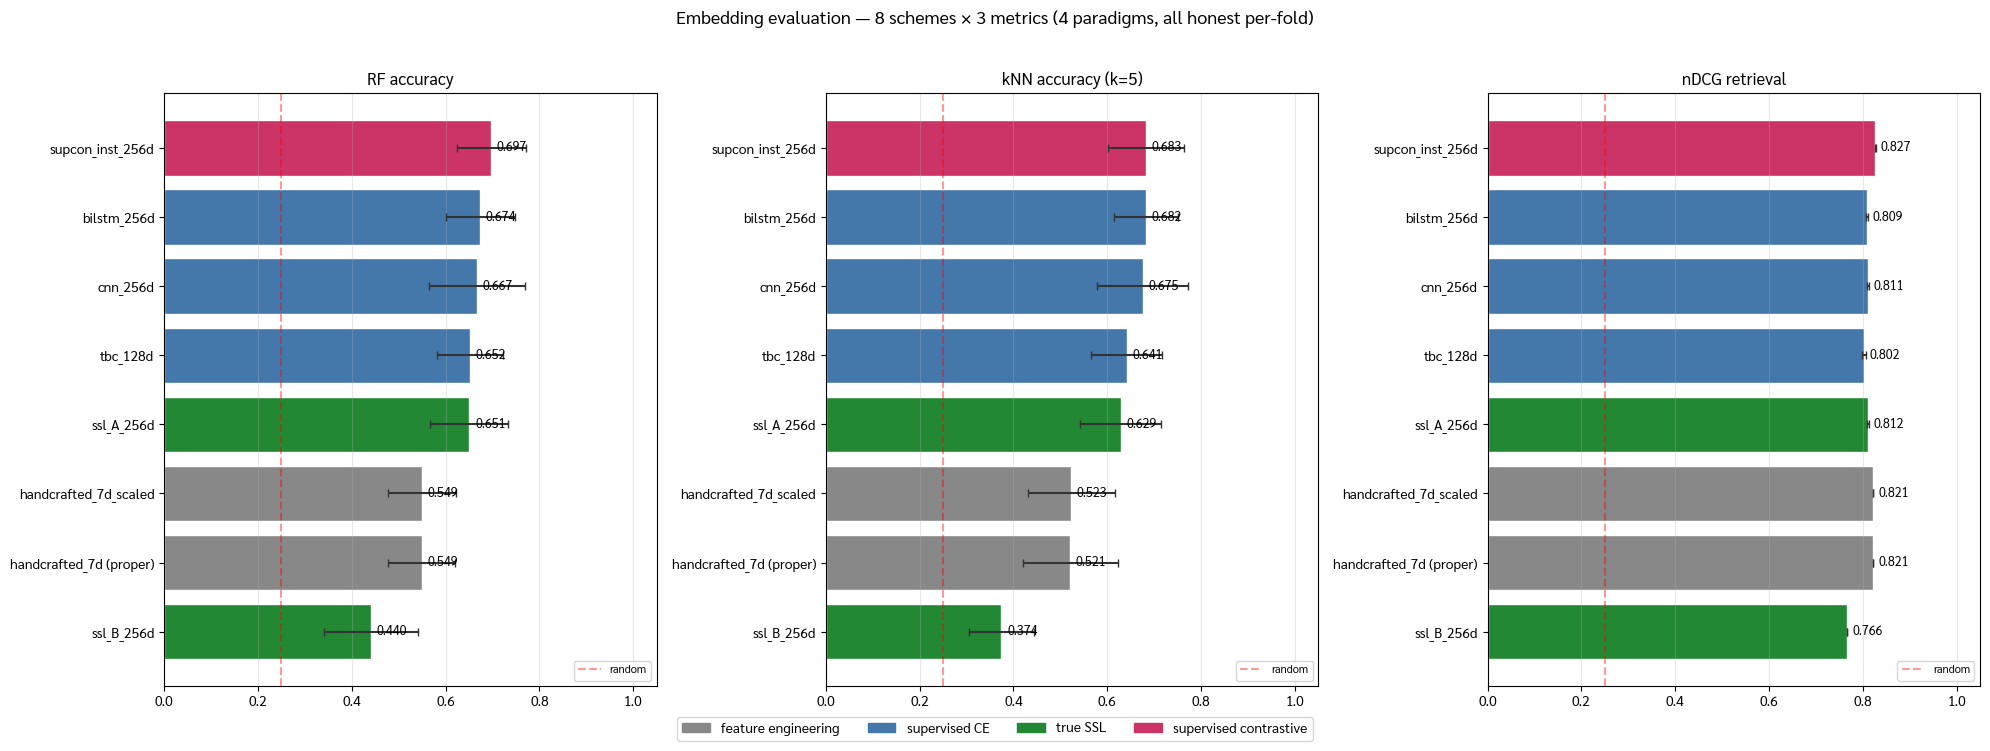


✓ saved → embedding_evaluation_full.csv + embedding_comparison_final.png


In [21]:
# Final comparison — 8 schemes × 3 metrics × 4 paradigms
emb_df = pd.DataFrame(emb_results).round(4)

display_cols = ['scheme', 'paradigm', 'dim',
                'rf_acc_mean', 'rf_acc_std',
                'knn_acc_mean', 'knn_acc_std',
                'ndcg', 'ndcg_std']
emb_df_display = emb_df[display_cols].copy()
display(emb_df_display)
save_table(emb_df_display, 'embedding_evaluation_full')

paradigm_colors = {
    'feature engineering':    '#888888',
    'supervised CE':          '#4477aa',
    'true SSL':               '#228833',
    'supervised contrastive': '#cc3366',
}

emb_df_sorted = emb_df.sort_values('rf_acc_mean').reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
metrics = [
    ('rf_acc_mean', 'rf_acc_std', 'RF accuracy'),
    ('knn_acc_mean', 'knn_acc_std', 'kNN accuracy (k=5)'),
    ('ndcg', 'ndcg_std', 'nDCG retrieval'),
]

for ax, (mean_col, std_col, title) in zip(axes, metrics):
    colors = [paradigm_colors[p] for p in emb_df_sorted['paradigm']]
    std_vals = emb_df_sorted[std_col].fillna(0).values
    bars = ax.barh(emb_df_sorted['scheme'], emb_df_sorted[mean_col],
                    xerr=std_vals, color=colors, edgecolor='white',
                    error_kw={'ecolor': '#333', 'capsize': 3})
    for bar, val in zip(bars, emb_df_sorted[mean_col]):
        ax.text(val + 0.012, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 1.05)
    ax.axvline(0.25, color='red', linestyle='--', alpha=0.4, label='random')
    ax.grid(axis='x', alpha=0.3)
    ax.legend(loc='lower right', fontsize=8)

import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=p) for p, c in paradigm_colors.items()]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=10,
            bbox_to_anchor=(0.5, 0.02))

plt.suptitle('Embedding evaluation — 8 schemes × 3 metrics (4 paradigms, all honest per-fold)',
              fontsize=13, y=1.02)
plt.tight_layout()
save_fig('embedding_comparison_final')
plt.show()

print("\n✓ saved → embedding_evaluation_full.csv + embedding_comparison_final.png")


Computing UMAP for 3 SSL variants...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ssl_A_256d (seed 0): (819, 256) → (819, 2)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ssl_B_256d (seed 0): (819, 256) → (819, 2)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  supcon_inst_256d (seed 0): (819, 256) → (819, 2)


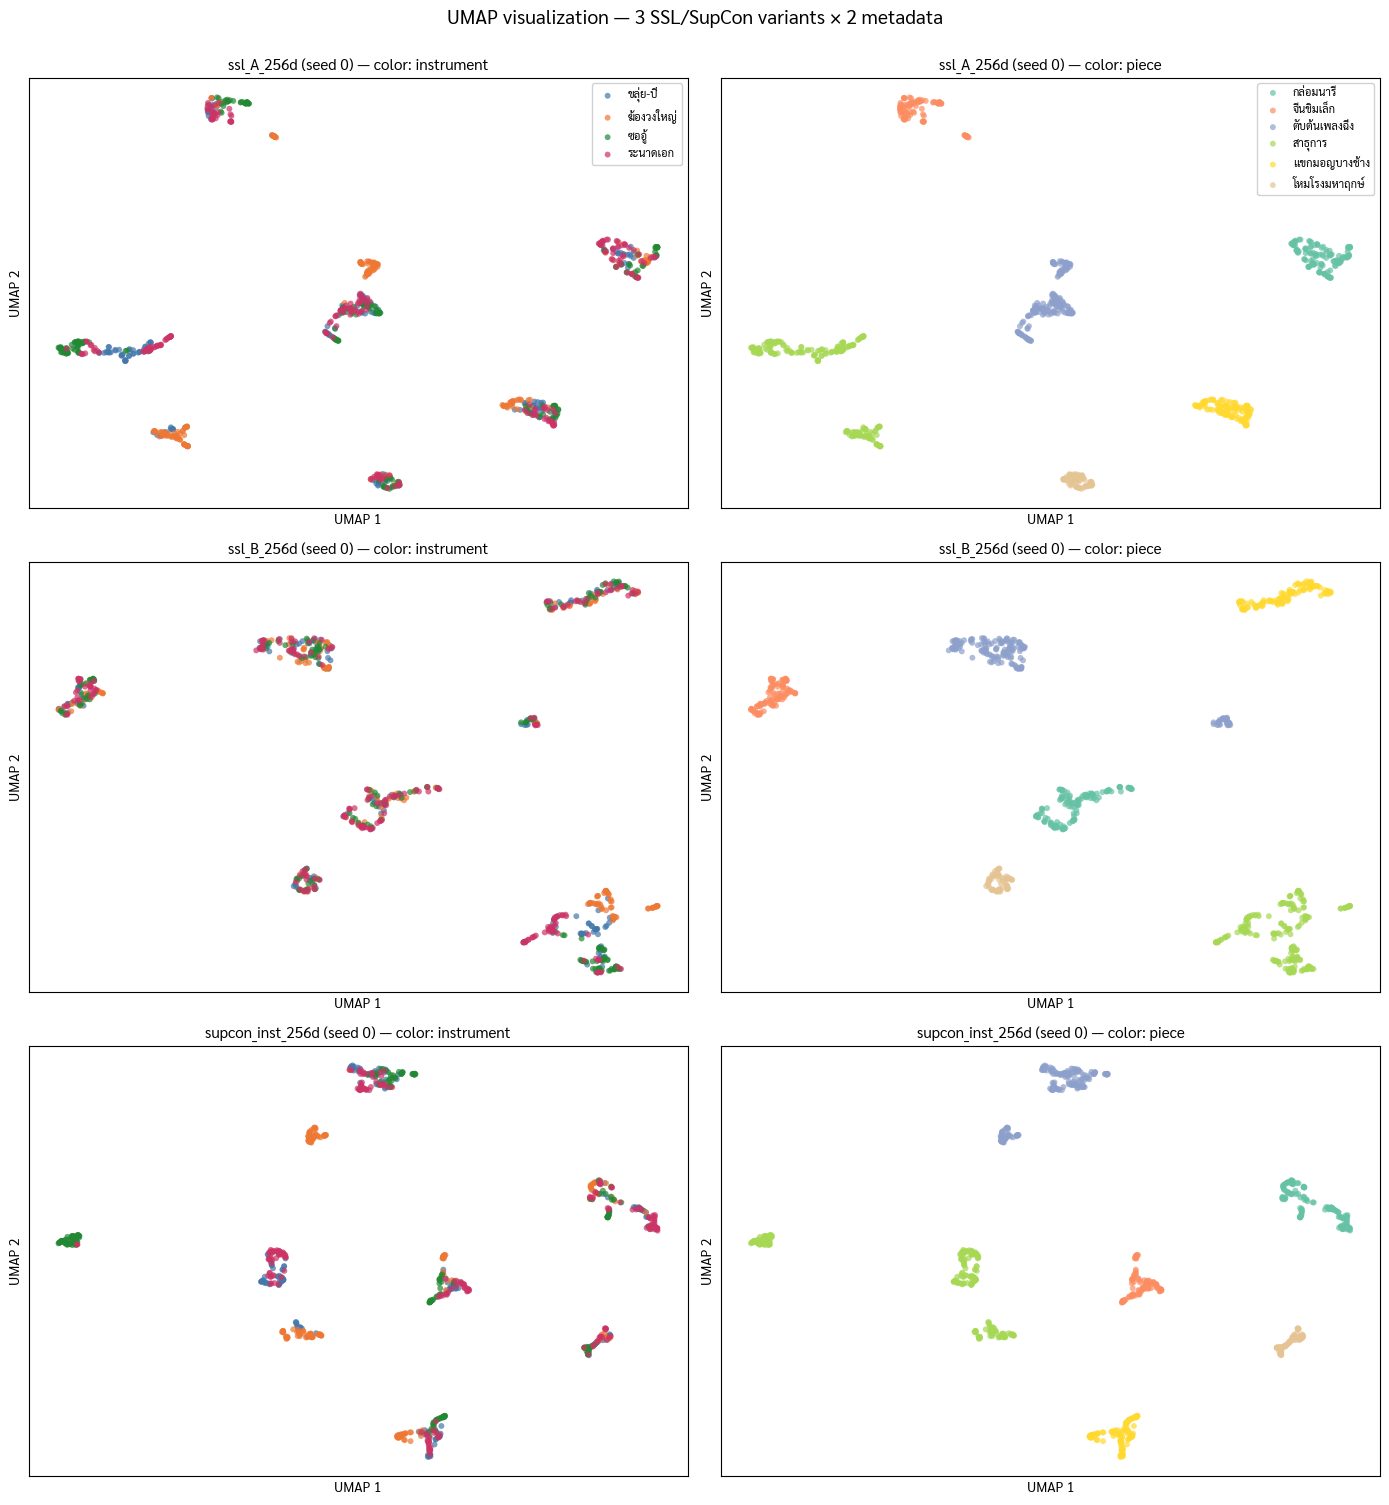


✓ saved → umap_grid_ssl_variants.png


In [22]:
# UMAP สำหรับ 3 SSL/SupCon variants — ตามรอย Section 4 pattern
print("Computing UMAP for 3 SSL variants...")

umap_inputs_ssl = {
    'ssl_A_256d (seed 0)':       embeddings['ssl_A_256d'][0],
    'ssl_B_256d (seed 0)':       embeddings['ssl_B_256d'][0],
    'supcon_inst_256d (seed 0)': embeddings['supcon_inst_256d'][0],
}

umap_2d_ssl = {}
for name, emb in umap_inputs_ssl.items():
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                         metric='cosine', random_state=42)
    umap_2d_ssl[name] = reducer.fit_transform(emb)
    print(f"  {name}: {emb.shape} → {umap_2d_ssl[name].shape}")


# Plot grid 3 schemes × 2 colors = 6 panels
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

schemes_ssl = list(umap_2d_ssl.keys())

for row, scheme in enumerate(schemes_ssl):
    coords = umap_2d_ssl[scheme]

    ax = axes[row, 0]
    for inst in INSTRUMENTS:
        mask = labels_inst == inst
        ax.scatter(coords[mask, 0], coords[mask, 1],
                    c=inst_colors[inst], label=inst, s=18, alpha=0.7, edgecolors='none')
    ax.set_title(f'{scheme} — color: instrument', fontsize=11)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    if row == 0:
        ax.legend(loc='best', fontsize=8, framealpha=0.9)
    ax.set_xticks([])
    ax.set_yticks([])

    ax = axes[row, 1]
    for piece in piece_unique:
        mask = labels_piece == piece
        ax.scatter(coords[mask, 0], coords[mask, 1],
                    c=[piece_colors[piece]], label=piece, s=18, alpha=0.7, edgecolors='none')
    ax.set_title(f'{scheme} — color: piece', fontsize=11)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    if row == 0:
        ax.legend(loc='best', fontsize=8, framealpha=0.9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('UMAP visualization — 3 SSL/SupCon variants × 2 metadata',
              fontsize=14, y=1.00)
plt.tight_layout()
save_fig('umap_grid_ssl_variants')
plt.show()
print("\n✓ saved → umap_grid_ssl_variants.png")

## 7. Musicological findings

ผลทั้ง 8 schemes (honest per-fold, 6 folds × 3 seeds):

| Scheme | Paradigm | RF | kNN | nDCG |
|---|---|---|---|---|
| handcrafted_7d_scaled | feature engineering | 0.549 ± 0.072 | 0.523 ± 0.093 | 0.821 |
| handcrafted_7d (proper) | feature engineering | 0.549 ± 0.072 | 0.521 ± 0.101 | 0.821 |
| cnn_256d | supervised CE | 0.667 ± 0.103 | 0.675 ± 0.097 | 0.811 |
| bilstm_256d | supervised CE | 0.674 ± 0.073 | 0.682 ± 0.068 | 0.809 |
| tbc_128d | supervised CE | 0.652 ± 0.071 | 0.641 ± 0.076 | 0.802 |
| ssl_A_256d | true SSL | 0.651 ± 0.083 | 0.629 ± 0.086 | 0.812 |
| ssl_B_256d | true SSL | 0.440 ± 0.100 | 0.374 ± 0.070 | 0.766 |
| **supcon_inst_256d** | **supervised contrastive** | **0.697 ± 0.073** | **0.683 ± 0.081** | **0.827** |

### Finding 1 — SupCon-inst ดีที่สุดในทุก metric แต่ margin บาง

SupCon-inst (supervised contrastive) นำทุก metric — แต่ห่างจาก supervised CE (BiLSTM)
เพียงเล็กน้อย:

| Metric | BiLSTM (best CE) | SupCon-inst | Δ |
|---|---|---|---|
| RF | 0.674 | 0.697 | +2.3% |
| kNN | 0.682 | 0.683 | +0.1% |
| nDCG | 0.809 | 0.827 | +1.8% |

**Interpretation:**

Margin +2.3% RF ตรงกับ literature (Khosla et al. 2020 SupCon paper) ที่รายงาน
SupCon ดีกว่า CE ราว 2-5% — **เป็น honest validation ว่า protocol ของเราถูกต้อง**

**Why SupCon (เพียงเล็กน้อย) ดีกว่า CE:**

- Supervised CE: optimize cross-entropy บน decision boundary — embedding space
  เป็น byproduct, structure ไม่ได้ถูก optimize ตรง ๆ
- SupCon: optimize embedding space ที่ same-class ใกล้กัน + different-class ไกลกัน
  → structure ของ embedding space ถูก optimize ตรง ๆ

แต่ใน dataset เล็ก (819 windows, 4 classes) — pair-wise vs point-wise label use
ให้ผลใกล้กัน

### Finding 2 — SSL-A เทียบ supervised CE ได้แค่ใน nDCG ไม่ใช่ classification

SSL-A (intra-song, ไม่ใช้ label) เทียบ BiLSTM:

| Metric | BiLSTM | SSL-A | Δ |
|---|---|---|---|
| RF | 0.674 | 0.651 | -2.3% |
| kNN | 0.682 | 0.629 | -5.3% |
| nDCG | 0.809 | 0.812 | +0.3% |

**Differs from Finding-Tori claim:**

Finding-Tori (Han et al. 2023) รายงานว่า SSL ชนะ supervised CE บน audio Korean folk songs
ของเรา **ไม่ confirm** ใน symbolic Thai music context — SSL-A ใกล้ supervised CE ใน
retrieval task (nDCG เท่ากัน) แต่แพ้ใน classification (RF -2.3%, kNN -5.3%)

**เหตุผลที่เป็นไปได้:**

1. **Symbolic data signal บาง** — vocab เล็ก (24 tokens), discrete; FT ใช้ continuous audio
   ที่มี timbre/intonation/ornament รวมกัน
2. **Dataset เล็กเกินสำหรับ SSL** — เรามี 819 windows; FT มี ~ล้าน segments
3. **SSL-A เรียน bundled signal** — positive = same song = same piece × same instrument
   → ใน leave-one-piece-out CV ที่ test piece ไม่เคยเห็น, SSL-A generalize ยากกว่า
   supervised CE ที่เรียน instrument ตรง ๆ
4. **Easy negatives** — random sampling จาก ~600 windows, หลาย negatives เป็นคนละ
   instrument → trivial ที่จะแยก ไม่บังคับให้เรียน fine-grained features

**Implication:** Finding-Tori SSL signal ไม่ generalize 1:1 ไป symbolic small-data
ของเรา — แต่ SSL-A ยังเป็น **competitive baseline ไม่มี label** (nDCG เท่ากับ
supervised CE)

### Finding 3 — SSL-B confirm piece coherence dominate (แต่ไม่ extreme)

SSL-B (cross-instrument same-piece) ลด RF จาก 0.674 (BiLSTM) → 0.440:

| Variant | What SSL captures | RF | kNN |
|---|---|---|---|
| SSL-A | song-level (piece + instrument bundled) | 0.651 | 0.629 |
| SSL-B | piece-level (across instruments) | 0.440 | 0.374 |

**Interpretation:**

เมื่อ positive pair = "เพลงเดียวกัน คนละเครื่อง" — model ถูกบังคับให้ embed
windows ของเครื่องต่างกัน-เพลงเดียวกันใกล้กัน → ลบ instrument signature

ใน Thai music ตามทฤษฎี: ลูกฆ้อง (skeletal melody) เป็น structural framework ที่
ทุกเครื่องร่วมใช้. SSL-B พิสูจน์ empirically ว่า piece coherence **เป็นสัญญาณจริง**
ใน data — เครื่องต่างกัน 4 ตัวบรรเลงเพลงเดียวกัน มี shared melodic core ที่ neural
detect ได้

**Important nuance:**

SSL-B RF 0.440 ยังสูงกว่า chance (0.25) — แสดงว่า piece signal **ไม่ได้ลบ instrument
ทั้งหมด** เพียงแต่ลดอย่างมีนัยสำคัญ. อาจเพราะ:
- บางท่อนของเพลงเดียวกันยังมี idiomatic patterns ของแต่ละเครื่องที่ SSL-B แยกไม่ออก
- 6 pieces ใน dataset อาจไม่ครอบคลุมพอที่จะลบ instrument ทั้งหมด

นี่ confirm UMAP จาก Section 4 ที่เห็นว่า supervised neural cluster ตาม **piece**
ก่อน instrument

### Finding 4 — Hand-crafted nDCG เทียบเท่า/ดีกว่า neural ทุกตัว ยกเว้น SupCon

| Scheme | RF | kNN | nDCG |
|---|---|---|---|
| handcrafted_7d | 0.549 | 0.521 | **0.821** |
| cnn_256d | 0.667 | 0.675 | 0.811 |
| bilstm_256d | 0.674 | 0.682 | 0.809 |
| tbc_128d | 0.652 | 0.641 | 0.802 |
| ssl_A_256d | 0.651 | 0.629 | 0.812 |
| supcon_inst_256d | 0.697 | 0.683 | 0.827 |

**Interpretation:**

- Hand-crafted **nDCG (0.821) สูงกว่า** supervised CE ทุกตัว — เทียบเท่า SSL-A (0.812)
  ใกล้ SupCon (0.827) เพียง -0.6%
- Hand-crafted **classification ต่ำกว่า neural ~12-13%** ใน RF, ~16% ใน kNN

**Why?** 7 hand-crafted features (sustain ratio, octave ratios, ลูกสบัด density,
paren ratio, transition entropy) เป็น signals ที่ **musically meaningful** —
windows ที่ใกล้กันในเชิงดนตรีมีค่า feature ใกล้กัน → local neighborhood ดี
(สะท้อนใน nDCG/kNN-like retrieval)

แต่ feature space 7-dim ไม่ linearly separable พอ → decision boundary แยก class ยาก
→ RF (non-linear) ต่ำกว่า neural 256-dim

**→ Hand-crafted ยังมี value สำหรับ retrieval/similarity task** ที่ต้นทุนต่ำกว่ามาก
(7 features vs 256-dim neural ที่ต้อง train + per-fold protocol)

### Finding 5 — Triangulation summary

| Variant | What it tests | RF | Interpretation |
|---|---|---|---|
| SSL-A | song-level signal | 0.651 | song coherence = bundle of piece + instrument; SSL ไม่ชนะ supervised ใน symbolic |
| SSL-B | piece coherence (ลบ instrument) | 0.440 | piece signal แข็ง — drop RF 0.23 vs supervised CE |
| SupCon | instrument-aware contrastive | 0.697 | label-aware best; margin บาง vs CE |

**Conclusion — what Thai music symbolic data really has:**

1. **Instrument signal extractable แต่ต้อง explicit supervision** — SupCon (0.697) >
   supervised CE (0.674) > SSL-A (0.651). Pair-wise label use ดีกว่า point-wise นิดเดียว
2. **Piece coherence เป็นสัญญาณรอง แต่จริง** — SSL-B drop 0.23 RF เทียบ supervised CE
   confirm ลูกฆ้อง shared structure ใน data
3. **Hand-crafted features capture musical similarity ดี** — nDCG 0.821 เทียบ neural ได้

### Implications for project

1. **Default architecture สำหรับ instrument classification:** **SupCon-inst** —
   ดีที่สุดในทุก metric (margin บาง แต่สม่ำเสมอ), เสถียร (std ~0.07-0.08)

2. **Piece bias เป็น risk จริง:** ตอนนี้ dataset 6 pieces — SSL-B drop confirm ว่า
   model มี piece information ติดอยู่. ในการ scale dataset (≥20 pieces) ต้อง:
   - Monitor performance gap ระหว่าง train piece vs test piece
   - ใช้ leave-one-piece-out CV เป็น default validation

3. **SSL-A ใช้เป็น label-free baseline:** nDCG เทียบเท่า supervised CE — ใช้ได้
   เมื่อไม่มี label หรือต้องการ retrieval ที่ไม่ pre-trained on instrument

4. **Hand-crafted features ใช้คู่กับ neural ได้:** สำหรับ retrieval/similarity
   (เช่น "หา window คล้ายกัน") hand-crafted ทำได้ใกล้ neural ที่ต้นทุนต่ำกว่ามาก

5. **Finding-Tori protocol ไม่ generalize 1:1 ไป symbolic small-data:** SSL ของ FT
   ที่ชนะ supervised CE บน 700hr audio — เมื่อ adapt ไป 819 symbolic windows
   ไม่ชนะอีกต่อไป. นี่ informative finding ตัวมันเอง — ไม่ใช่ความล้มเหลว แต่เป็น
   condition ที่ต่างกัน

### Future directions

1. **Scale dataset ≥ 20 pieces** — ตอนนี้ 6 pieces ทำให้ piece bias ชัด;
   เพิ่ม pieces จะลด SSL-A กับ supervised CE gap

2. **Hard negative mining สำหรับ SSL-A** — ตอนนี้ random sampling ใน large negative pool
   ทำให้ SSL signal "easy". ลองใช้ same-instrument-different-song เป็น hard negatives
   อาจช่วยให้ SSL จับ fine-grained patterns

3. **SSL-A pretrain → fine-tune supervised** — แม้ SSL-A เดี่ยวไม่ชนะ supervised
   ลองใช้เป็น initialization สำหรับ supervised — อาจช่วยตอน fine-tune

4. **Piece-instrument retrieval application** — ใช้ embedding space (โดยเฉพาะ
   hand-crafted ที่ nDCG สูง) ทำ tool สำหรับนักดนตรีตามหา variant ของเพลง
   ในเครื่องอื่น

5. **Annotate ทาง (idiom/lineage) ของแต่ละ piece** — เพิ่ม metadata axis ที่ 3
   นอกจาก piece + instrument; ทดสอบว่า embedding capture lineage ได้ไหม